In this notebook, I initialize an AKLT chain, make spin measurements, and evolve approximately by the AKLT Hamiltonian by trotterizing. 

In [ ]:
import numpy as np
import functools as ft


from itertools import product

from qiskit import QuantumCircuit, transpiler, QuantumRegister, ClassicalRegister, AncillaRegister, transpile
from qiskit.circuit import Parameter
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.synthesis import SuzukiTrotter

from qiskit_aer import AerSimulator

import matplotlib.pyplot as plt
import matplotlib.ticker as tck

Initialize the MPS matrices and Hilbert space basis

In [2]:
A_plus = np.sqrt(2/3) * np.array([[0,1],[0,0]],dtype= complex)
A_zero = - np.sqrt(1/3) * np.array([[1,0],[0,-1]], dtype= complex)
A_minus = - np.sqrt(2/3) * np.array([[0,0],[1,0]],dtype= complex)

A = {
    "+" : A_plus,
    "0" : A_zero,
    "-" : A_minus
}

triplet_basis = {
    "+" : np.array([1,0,0,0], dtype =complex),
    "0" : 1/np.sqrt(2) * np.array([0,1,1,0],dtype= complex) ,
    "-" : np.array([0,0,0,1], dtype =complex)
}


Build N qubit periodic chain statevector

In [3]:
def AKLT_MPS(num_sites):

    num_qubits = num_sites*2
    psi = np.zeros(2** num_qubits, dtype= complex)
    coef_squar_total = 0

    for s in  product(["+","0","-"], repeat = num_sites):
        
        # calculate MPS coefficient (trace uses perioic boundary conditions. 
        # To implement open boundary conditions find inner product of chain of matrices w.r.t. 
        # vL = [1,0] and vR = [0,1])
        MPS_array = [A[i] for i in s]
        coeff_matrix = np.identity(2, dtype= complex)
        for e in MPS_array:
            coeff_matrix @= e
        coeff = np.trace(coeff_matrix)

        coef_squar_total += coeff **2

        #construct the state from Kronecker producs
        State_array = [triplet_basis[i] for i in s]
        local_state = ft.reduce(np.kron, State_array)

        psi += (coeff ) * local_state

    #normalize
    psi = psi/np.sqrt(coef_squar_total)
    return psi

Create the circuit. The number of qubits needed to initialize and evolve the AKLT system is twice the number of sites, but measurement of the spin-1 sector without projecting into the spin-0 sector will require two additional ancilla qubits. Additionally, we will need 4 classical bits to record the first and second measurements of the ancillas.

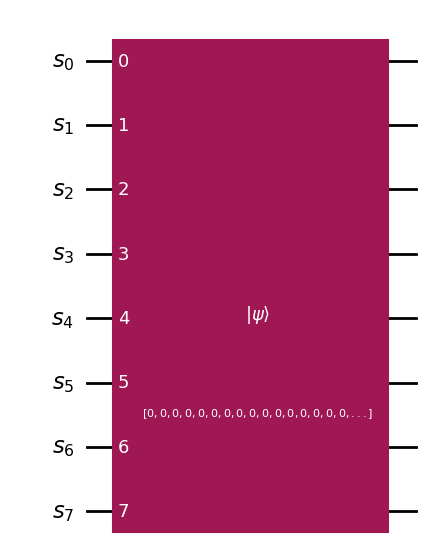

In [ ]:
num_sites = 4
psi = AKLT_MPS(num_sites)
num_qubits = num_sites * 2
state_qubits = QuantumRegister(num_qubits, "s")
ancilla_qubits = AncillaRegister(2, "a")
classical_bits = ClassicalRegister(4, "c")
qc = QuantumCircuit(state_qubits , ancilla_qubits, classical_bits)
qc.initialize(psi, range(num_qubits))
sv = Statevector(psi)

qc.draw(output="mpl",  idle_wires= False, style ="iqp")

The first quantity which is useful to us is $C(t) =  \langle \frac{1}{2}\{S^z_n( 0), S^z_n(t)\}\rangle $. This is the quantity which is used in Barry and Yuntao's paper but it is only strictly relevant for dichotomic systems. Nonetheless, we will want to calculate it because it is easy and we will want to see how good of an approximator it is. 

Going forward however, if we calculate the same quantity (S10 in their SM) for a trichotomic system like $S^z$, then we get the slightly messier

$C(t) = \langle  S^z(0) \frac{1}{2}\{S^z(t) , S^z(0) \}  S^z(0)  \rangle$.

This uses the projection operator $\Pi(q) = (1 - q^2) + \frac{1}{2}q Q +(\frac{3}{2} q^2 -1 ) Q^2$

Construct the measurement operator for $S_n^z$ of the nth spin-1 site corresponding to $S_n^z = \frac{1}{2}(\sigma^z_{2n} + \sigma^z_{2n+1})$, then construct the operator $\vec S_n \cdot \vec S_{n+1} =\frac{1}{4} \sum_i (\sigma^i_{2n}\sigma^i_{2n+2} + \sigma^i_{2n}\sigma^i_{2n+3} + \sigma^i_{2n+1}\sigma^i_{2n+2} + \sigma^i_{2n+1}\sigma^i_{2n+3})$  where all indices are mod num_sites and $\sigma^i$ is the Pauli matrix and not the spin-1/2 operator.

Finally, the Hamiltonian, which is 

$\hat H = \sum_{j} \vec S_j \cdot \vec S_{j+1}+ \frac{1}{3} (\vec S_j \cdot \vec S_{j+1})^2$

In [4]:
def shift_string(pauli_string, shift):
    """Shifts a Pauli string by n places (rotates right), wrapping around."""
    shift = -shift % len(pauli_string)
    return pauli_string[shift:] + pauli_string[:shift]

def Sn_string_1(num_qubits, n_site, axis ):
    return "I" *n_site*2  + axis +"I" + "I"*(num_qubits-2 * n_site-2)
def Sn_string_2(num_qubits, n_site, axis):
    return "I" *n_site*2  + "I" + axis + "I"*(num_qubits-2 * n_site-2)
def Sn(num_qubits, n_site, axis): #returns spin-1 evaluation of site n_site along the 'axis' \in ["X","Y","Z"]
    return SparsePauliOp.from_list([(Sn_string_1(num_qubits, n_site, axis),0.5),(Sn_string_2(num_qubits, n_site, axis),0.5)])

def SSn_string_n1_n2(num_qubits, qbit1, dist, axis ): #creates the string compatable with SparsePauliOp.from_list for sigma sigma operators 
    #with the first sigma at qbit1 and the second sigma at qbit1 + dist
    return shift_string(axis+"I"*(dist-1) +axis +"I"* (num_qubits-dist-1) , qbit1)

def SSn(num_qubits, n_site): #generates the sparse Pauli operator for the S dot S term between sites n_site and n_site + 1
    
    return SparsePauliOp.from_list([(SSn_string_n1_n2(num_qubits,n_site*2+k,j-k,a),0.25) for a in ["X","Y","Z"] for k in range(2)  for j in range(2,4)  ] )

def Hamiltonian_even(num_qubits): 
    """Operators which connect only bonds which start with even site index"""

    num_sites = num_qubits//2

    if num_sites % 2 == 0:
        num_even = num_sites//2
    else:
        num_even = num_sites//2 + 1
    
    SS = SparsePauliOp.from_list([(SSn_string_n1_n2(num_qubits,i*4+k,j-k,a) ,0.25)
                                    for i in range(num_even) for j in range(2,4) for a in ["X","Y","Z"] for k in range(2) ] )
    
    SSSS = SparsePauliOp.from_list([("I"*num_qubits, 0.0)])

    for i in range(num_even ):
    
        SSSS += SSn(num_qubits, i*2).dot(SSn(num_qubits, i*2))
    
    identity = SparsePauliOp.from_list([("I"*num_qubits, 1.0)])
        
    return (1.0 * SS + 1.0/3.0 *SSSS + 2.0 * num_even /3.0 * identity  ).simplify()

def Hamiltonian_odd(num_qubits): 
    """Operators which connect only bonds which start with odd site index"""

    num_sites = num_qubits//2
    num_odd = num_sites//2 

    SS = SparsePauliOp.from_list([(SSn_string_n1_n2(num_qubits,(i*2 +1)*2+k,j-k,a) ,0.25)
                                    for i in range(num_odd) for j in range(2,4) for a in ["X","Y","Z"] for k in range(2) ] )
    
    SSSS = SparsePauliOp.from_list([("I"*num_qubits, 0.0)])

    for i in range(num_odd ):
    
        SSSS += SSn(num_qubits, i*2+1).dot(SSn(num_qubits, i*2 +1))
    
    identity = SparsePauliOp.from_list([("I"*num_qubits, 1.0)])
        
    return (1.0 * SS + 1.0/3.0 *SSSS + 2.0 * num_odd /3.0 * identity  ).simplify()

def Hamiltonian(num_qubits):
   return  Hamiltonian_even(num_qubits) + Hamiltonian_odd(num_qubits)

def bond(): #generates the S dot S term for a single bond between two sites, compatable with PauliEvolutionGate
    SS = SparsePauliOp.from_list([(SSn_string_n1_n2(4,k,j-k,a),0.25) for a in ["X","Y","Z"] for k in range(2)  for j in range(2,4)  ] )
    return (SS + 1/3 *SS.dot(SS) + 2/3 * SparsePauliOp.from_list([("I"*4, 1.0)])).simplify()



We now have to evolve the wavefunction. This will be done using Qiskit's native gate which trotterizes an input operator for one time step. This is why I separated the Hamiltonian into odd and even sites because (if num_sites is even) all even bonds commute with each other and all odd bonds commute with each other. This reduces the Trotter error. Additionally, we can mitigate error by using the Suzuki method for Trotterizing wherein we implement the second order technique where instead of $\epsilon \propto \mathcal O(\delta t^2)$ we have $\epsilon \propto \mathcal O (\delta t^3)$. This is especially important because of the $(S \cdot S)^2$ term in our Hamiltonian. 

We will also employ a method of error mitigation by time evolving as such:

$U_e(\delta t/2) U_o(\delta t) U_e(\delta t)U_o(\delta t)... U_o(\delta t)U_e(\delta t/2)$

In [5]:
def gate_even(qc, num_sites, delta):
    """Returns the Trotterized time evolution circuit element for the even bonds."""
    if num_sites % 2 == 0:
        num_even = num_sites//2
    else:
        return "error - even number of sites required for even bond evolution"

    for i in range(num_even):
        qc.append(PauliEvolutionGate(bond(), delta , 
                                     synthesis=SuzukiTrotter(order = 2, reps = 2),label = "$\\exp(- i H_e $"+ str(delta) + ")"), range(4 * i, 4 * i + 4))

def gate_odd(qc, num_sites, delta):
    """Returns the Trotterized time evolution circuit element for the odd bonds."""
    if num_sites % 2 == 0:
        num_odd = num_sites//2
    else:
        return "error - even number of sites required for odd bond evolution"

    for i in range(num_odd):
        qc.append(PauliEvolutionGate(bond(), delta , 
                                     synthesis=SuzukiTrotter(order = 2, reps = 2), label = "$\\exp(- i H_o $"+ str(delta) + ")"), [(4 * i +2+j )% (2 * num_sites) for j in range(4)] )

def evolution_gate(qc, num_sites, time, delta):
    """Returns the Trotterized time evolution circuit element by the method described above."""

    num_steps = int(time/delta)
    gate_even(qc, num_sites, delta/2)
    for i in range(num_steps-1):
        gate_odd(qc, num_sites, delta)
        gate_even(qc, num_sites, delta)

    gate_odd(qc, num_sites, delta)
    gate_even(qc, num_sites, delta/2)


To properly visualize what is happening, let's draw a quick circuit diagram

In [6]:
num_sites = 4
psi = AKLT_MPS(num_sites)
num_qubits = num_sites * 2
state_qubits = QuantumRegister(num_qubits, "s")
ancilla_qubits = AncillaRegister(2, "a")
classical_bits = ClassicalRegister(4, "c")
qc = QuantumCircuit(state_qubits , ancilla_qubits, classical_bits)
qc.initialize(psi, range(num_qubits))

evolution_gate(qc, num_sites, .1, 3)
#qc.draw(output="mpl",  idle_wires= True, style ="iqp")

We also need to construct the measurement circuit components. What this does is couple a pair of ancilla qubits to the spin to be measured. By measuring the ancillas, we can determine the total spin of the two qubits without projecting into the spin-0 sector. 

In [7]:
def measure_Sz(qc, n_site, instance): 
    qc.cx(n_site*2, ancilla_qubits[0])
    qc.cx(n_site*2 +1, ancilla_qubits[0]) # measures the parity of the two qubits encoding the spin-1 site

    qc.ccx(n_site*2, n_site*2 +1, ancilla_qubits[1]) # measures the product of the two qubits encoding the spin-1 site
    qc.measure(ancilla_qubits[0], classical_bits[instance * 2])
    qc.measure(ancilla_qubits[1], classical_bits[instance * 2 + 1])


Now that we have everything together for the simplest version of the Legget-Garg AKLT experiment, we can construct the circuit with measurements in order to construct the correlation function. In theory, this should be doable on native hardware for 4 sites. After a check that everything is running properly, and that the LG inequality is violated, I will move to more sites and a simulator. 

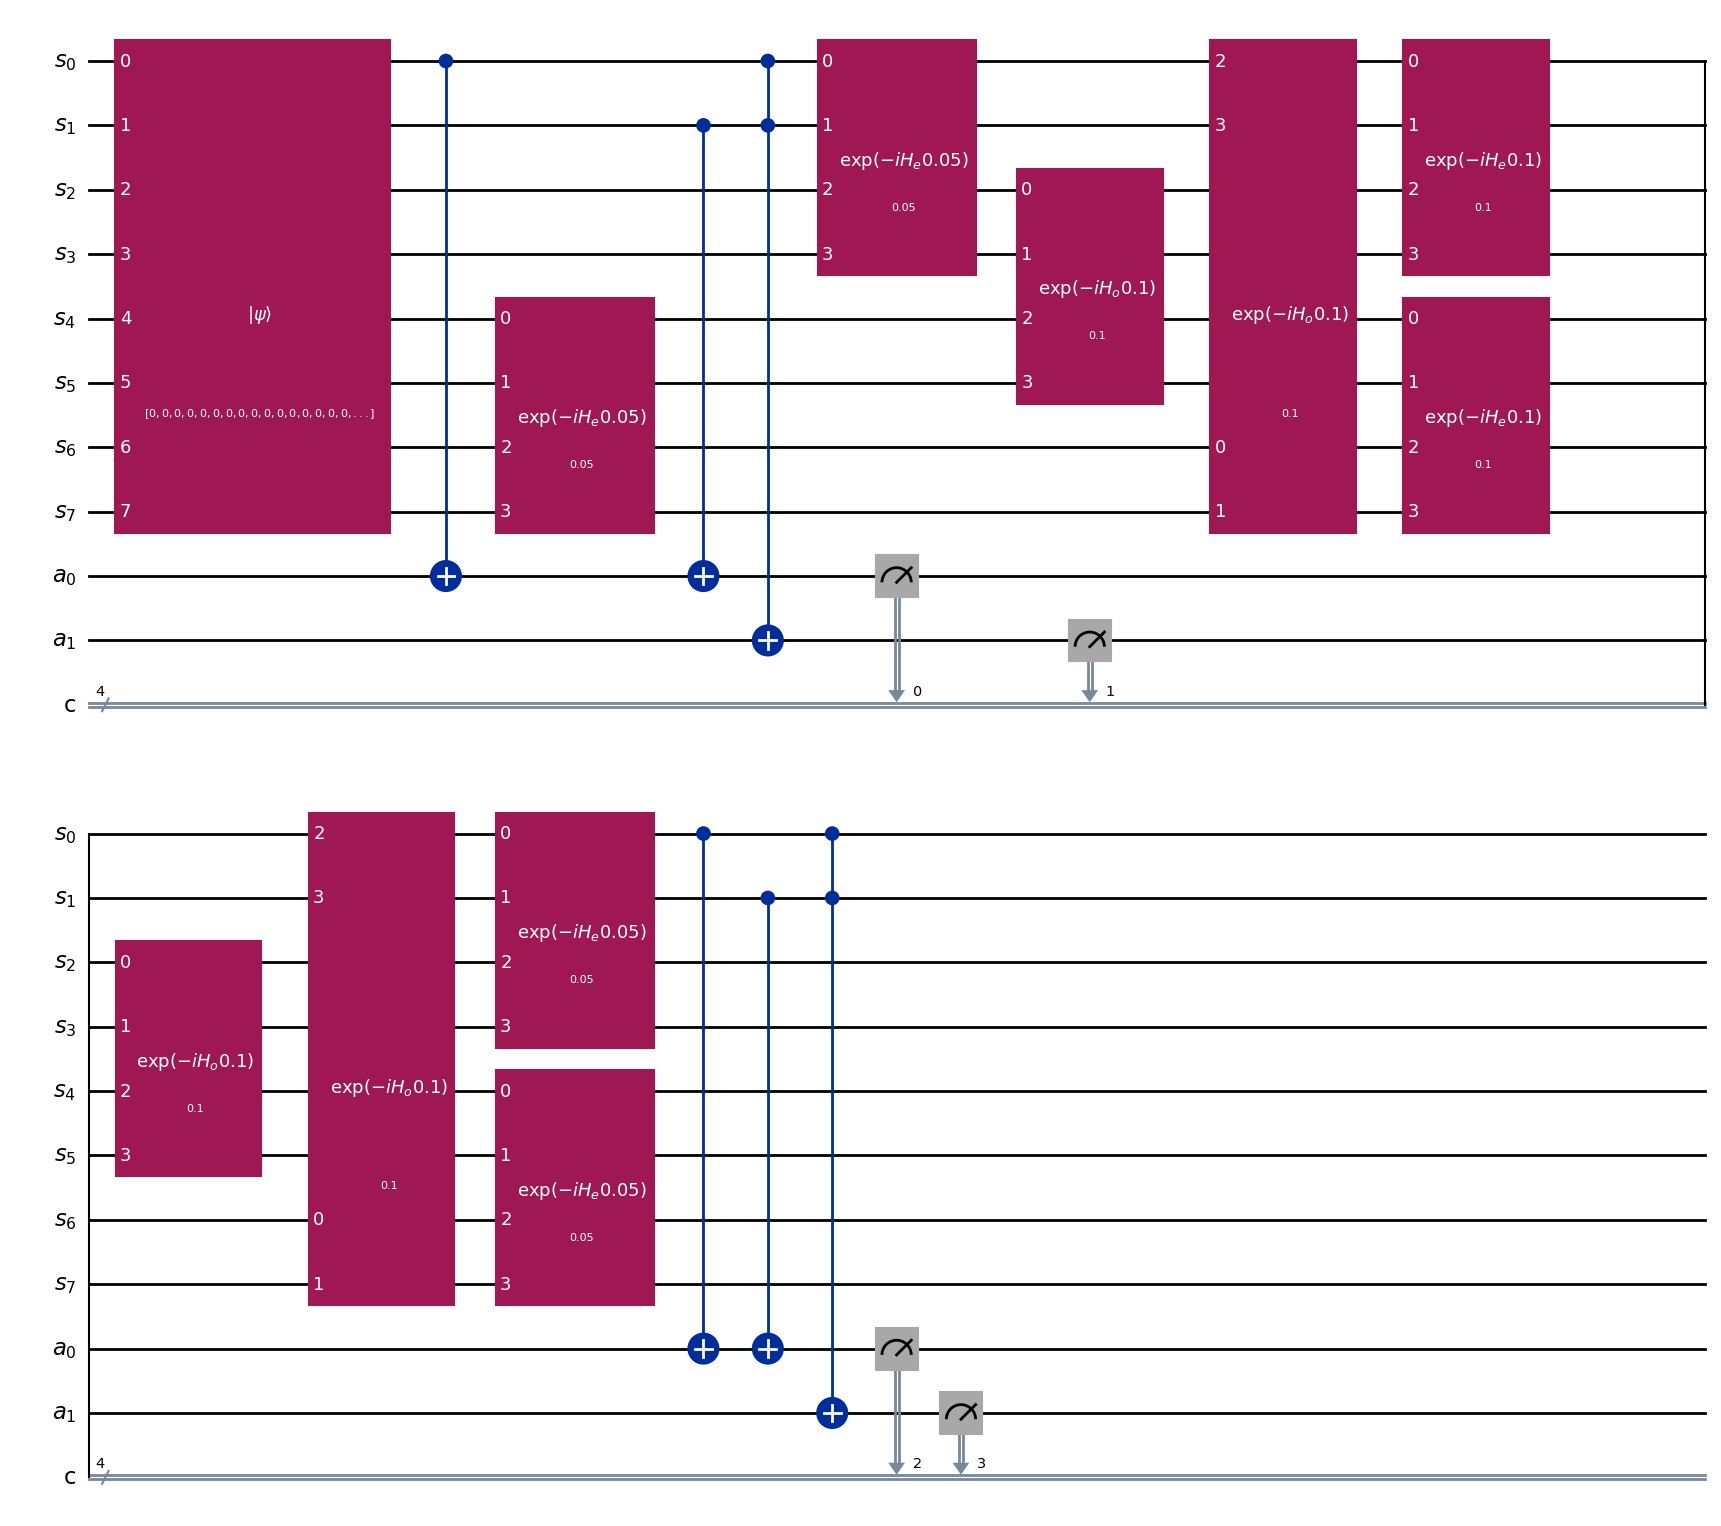

In [9]:
num_sites = 4
psi = AKLT_MPS(num_sites)
num_qubits = num_sites * 2
state_qubits = QuantumRegister(num_qubits, "s")
ancilla_qubits = AncillaRegister(2, "a")
classical_bits = ClassicalRegister(4, "c")
qc = QuantumCircuit(state_qubits , ancilla_qubits, classical_bits)
qc.initialize(psi, range(num_qubits))

measure_Sz(qc, 0, 0)
evolution_gate(qc, num_sites, time = 0.2, delta = 0.1)
measure_Sz(qc, 0, 1)

qc.draw(output="mpl",  idle_wires= True, style ="iqp")


Introduce a list of time values

In [12]:
num_times = 21
end_time = 2
times = np.linspace(0, end_time , num_times)
#Times should be expressed as a list of lists in order to work
individual_times = [[t] for t in times]

backend = AerSimulator() #AerSimulator() runs locally
qc = transpile(qc, backend) 

#run the circuit num_shots times
num_shots = 1000
job = backend.run(qc, shots = num_shots)
result = job.result()
counts = result.get_counts(qc)



In [13]:
print(counts)

{'0010': 316, '0000': 319, '1010': 1, '0001': 296, '1101': 19, '0100': 17, '0101': 23, '1110': 9}
